# Reciprocity Analysis

In [2]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import os
import gc
import sys
import statsmodels.formula.api as smf
from IPython.display import HTML
import numpy as np
import pandas as pd
from stargazer.stargazer import Stargazer

In [3]:
required_columns = [
    'phase',
    'hasAnswer',
    'numHelped',
    'userId',
    'year',
    'userFeNumHelped',
    'numHelpProvidedAT',
    'numQuestionsAskedAT',
    'logNumHelpProvidedAT',
    'logNumQuestionsAskedAT',
    'timeSinceFirstActivityDays',
    'initialExperienceReceiving',
    'initialExperienceGiving'
]

df_rec = pd.read_parquet('../data/study_datasets/question_centered_model_7d.parquet', columns=required_columns)
df_rec['logtimeSinceFirstActivityDays'] = np.log(1 + df_rec['timeSinceFirstActivityDays'])

print("\nColumn names for df_rec:")
print(df_rec.columns.tolist())


Column names for df_rec:
['phase', 'hasAnswer', 'numHelped', 'userId', 'year', 'userFeNumHelped', 'numHelpProvidedAT', 'numQuestionsAskedAT', 'logNumHelpProvidedAT', 'logNumQuestionsAskedAT', 'timeSinceFirstActivityDays', 'initialExperienceReceiving', 'initialExperienceGiving', 'logtimeSinceFirstActivityDays']


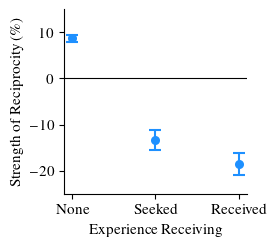

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

filtered_df = df_rec[(df_rec['numQuestionsAskedAT'].isin([0, 1]))]
user_ids_both_0_and_1 = filtered_df.groupby('userId')['numQuestionsAskedAT'].apply(lambda x: set(x) == {0, 1}).reset_index()
user_ids_both_0_and_1 = user_ids_both_0_and_1[user_ids_both_0_and_1['numQuestionsAskedAT'] == True]['userId']
filtered_df = filtered_df[filtered_df['userId'].isin(user_ids_both_0_and_1)]

mean_numHelped_by_user = filtered_df.groupby(['userId', 'phase'])['numHelped'].transform('mean')
filtered_df['numHelpedUserFE'] = filtered_df['numHelped'] - mean_numHelped_by_user
filtered_df['logtimeSinceFirstActivityDays'] = np.log(1 + filtered_df['timeSinceFirstActivityDays'])


formula = 'numHelpedUserFE ~ C(phase)*C(initialExperienceReceiving)*C(hasAnswer) + C(phase)*C(hasAnswer)*logtimeSinceFirstActivityDays + C(year)'

# Fit the logistic model using the formula and clustered standard errors
model_rec1 = smf.ols(formula=formula, data=filtered_df).fit(cov_type='cluster', cov_kwds={'groups': filtered_df['userId']})

def set_size(width=433.62, fraction=1, height_scale=1.0, equal_height_to_fraction_1=False):
    """
    Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width : float
        The document's text width in points.
    fraction : float
        The fraction of the width that the figure should occupy.
    height_scale : float
        A factor to scale the figure's height.
        - 1.0 (default): Uses the standard golden ratio height.
        - > 1.0: Makes the plot taller.
        - < 1.0: Makes the plot shorter.
    equal_height_to_fraction_1 : bool
        If True, calculates height based on the full document width, not the
        fractional width.
    """
    # Calculate the width in inches
    fig_width_pt = width * fraction
    inches_per_pt = 1 / 72.27
    fig_width_in = fig_width_pt * inches_per_pt

    # Use the golden ratio for a pleasing aspect ratio
    golden_ratio = (5**0.5 - 1) / 2

    # Determine the base height
    if equal_height_to_fraction_1:
        # Base height is calculated from the full document width (makes it tall)
        base_height_in = (width * inches_per_pt) * golden_ratio
    else:
        # Base height is calculated from the fractional figure width
        base_height_in = fig_width_in * golden_ratio

    # Apply the custom height scaling factor
    fig_height_in = base_height_in * height_scale

    return (fig_width_in, fig_height_in)

def create_plot_from_model(model, df_rec):
    """
    Creates a plot from a pre-run statsmodels OLS results object.

    This function assumes the model has been fitted with a formula including
    the term 'phase:C(initialExperienceReceiving):hasAnswer' and that
    'help received' is the reference level for the 'initialExperienceReceiving'
    categorical variable.

    Parameters:
    ----------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        The fitted OLS model object from which to extract coefficients.
    df_rec : pd.DataFrame
        The original DataFrame containing the 'numHelped' column, used to
        calculate the population mean for scaling the effect sizes.
    """
    # =============================================================================
    # 1. Define Coefficient Names Based on Your Model
    # =============================================================================
    # NOTE: These names must exactly match the output of model.summary()

    # Baseline effect, which you've specified corresponds to "help received"
    baseline_coef_name = 'C(phase)[T.2]:C(hasAnswer)[T.1]'

    # Additional effects for the other two groups
    seeked_interaction_coef_name = 'C(phase)[T.2]:C(initialExperienceReceiving)[T.help seeked]:C(hasAnswer)[T.1]'
    no_seeked_interaction_coef_name = 'C(phase)[T.2]:C(initialExperienceReceiving)[T.no help seeked]:C(hasAnswer)[T.1]'

    # =============================================================================
    # 2. Extract Coefficients and Calculate Combined Effects & Standard Errors
    # =============================================================================
    # Extract parameters and the variance-covariance matrix from your model
    params = model.params
    vcov = model.cov_params()

    # --- Calculate total effects for each group ---
    # The effect for "help received" is the baseline coefficient itself.
    effect_received = params[baseline_coef_name]

    # The effect for "help seeked" is the baseline + its specific interaction term.
    effect_seeked = params[baseline_coef_name] + params[seeked_interaction_coef_name]

    # The effect for "no help seeked" is the baseline + its specific interaction term.
    effect_no_seeked = params[baseline_coef_name] + params[no_seeked_interaction_coef_name]

    # --- Calculate standard errors for the effects ---
    # SE for "help received" is the SE of the baseline.
    se_received = model.bse[baseline_coef_name]

    # SE for "help seeked" must be calculated from the covariance matrix.
    # Var(A+B) = Var(A) + Var(B) + 2*Cov(A,B)
    var_baseline = vcov.loc[baseline_coef_name, baseline_coef_name]
    var_seeked = vcov.loc[seeked_interaction_coef_name, seeked_interaction_coef_name]
    cov_baseline_seeked = vcov.loc[baseline_coef_name, seeked_interaction_coef_name]
    se_seeked = np.sqrt(var_baseline + var_seeked + 2 * cov_baseline_seeked)

    # SE for "no help seeked" is also calculated from the covariance matrix.
    var_no_seeked = vcov.loc[no_seeked_interaction_coef_name, no_seeked_interaction_coef_name]
    cov_baseline_no_seeked = vcov.loc[baseline_coef_name, no_seeked_interaction_coef_name]
    se_no_seeked = np.sqrt(var_baseline + var_no_seeked + 2 * cov_baseline_no_seeked)

    # =============================================================================
    # 3. Normalize to Percentage and Generate Plot
    # =============================================================================

    # Calculate the population mean from the original, un-demeaned data
    pop_mean_numHelped = df_rec['numHelped'].mean()
    if pop_mean_numHelped == 0:
        print("Warning: Population mean is zero. Percentage effect size cannot be calculated.")
        pop_mean_numHelped = 1 # Avoid division by zero

    # Create a DataFrame for plotting in the desired order
    plot_data = pd.DataFrame({
        'Category': [r'None', r'Seeked', r'Received'],
        'Effect': [effect_no_seeked, effect_seeked, effect_received],
        'StdError': [se_no_seeked, se_seeked, se_received]
    })

    # Convert to percentage effect size
    plot_data['Effect_Percent'] = (plot_data['Effect'] / pop_mean_numHelped) * 100
    plot_data['StdError_Percent'] = (plot_data['StdError'] / pop_mean_numHelped) * 100

    # --- Plot Generation ---
    plt.rcParams['text.latex.preamble'] = r"\usepackage{txfonts}"
    params = {'text.usetex': True, 'font.size': 11, 'font.family': 'serif'}
    plt.rcParams.update(params)

    fig, ax = plt.subplots(figsize=set_size(fraction=0.48, height_scale=0.7, equal_height_to_fraction_1=True))

    ax.errorbar(
        x=plot_data['Category'],
        y=plot_data['Effect_Percent'],
        yerr=plot_data['StdError_Percent'],
        marker='o',              # Use a dot for the effect size
        linestyle='None',         # Connect dots with a dashed line
        capsize=4,               # Size of the error bar caps
        color='dodgerblue',      # Color for the line, markers, and error bars
        elinewidth=1.5,          # Thickness of the error bar lines
        markeredgewidth=1.5,     # Edge thickness of the markers
        markersize=5             # Size of the markers
    )
    ax.set_ylim(-25, 15)

    # print(plot_data)
    ax.set_ylabel(r'Strength of Reciprocity (\%)')
    ax.set_xlabel(r'Experience Receiving')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.grid(True, linestyle='None', which='major', color='gray', alpha=0.5)
    ax.set_axisbelow(True)
    fig.tight_layout()

    output_filename = "../plots/reciprocity_exp_receiving.eps"
    plt.savefig(output_filename, format='eps', dpi=1000, bbox_inches='tight')
    # print(f"Plot saved successfully as {output_filename}")
    plt.show()

create_plot_from_model(model=model_rec1, df_rec=filtered_df)

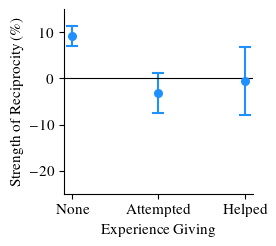

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

filtered_df = df_rec[(df_rec['numQuestionsAskedAT'].isin([0,1,2,3,4,5])) & (df_rec['numHelpProvidedAT'].isin([0, 1]))]
user_ids_both_0_and_1 = filtered_df.groupby('userId')['numHelpProvidedAT'].apply(lambda x: set(x) == {0, 1}).reset_index()
user_ids_both_0_and_1 = user_ids_both_0_and_1[user_ids_both_0_and_1['numHelpProvidedAT'] == True]['userId']
filtered_df = filtered_df[filtered_df['userId'].isin(user_ids_both_0_and_1)]

mean_numHelped_by_user = filtered_df.groupby(['userId', 'phase'])['numHelped'].transform('mean')
filtered_df['numHelpedUserFE'] = filtered_df['numHelped'] - mean_numHelped_by_user
filtered_df['logtimeSinceFirstActivityDays'] = np.log(1 + filtered_df['timeSinceFirstActivityDays'])

formula = 'numHelpedUserFE ~ C(phase) * C(initialExperienceGiving) * C(hasAnswer) + C(phase)*C(hasAnswer)*logtimeSinceFirstActivityDays + C(year)'

# Fit the logistic model using the formula and clustered standard errors
model_rec2 = smf.ols(formula=formula, data=filtered_df).fit(cov_type='cluster', cov_kwds={'groups': filtered_df['userId']})


def set_size(width=433.62, fraction=1, height_scale=1.0, equal_height_to_fraction_1=False):
    """
    Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width : float
        The document's text width in points.
    fraction : float
        The fraction of the width that the figure should occupy.
    height_scale : float
        A factor to scale the figure's height.
        - 1.0 (default): Uses the standard golden ratio height.
        - > 1.0: Makes the plot taller.
        - < 1.0: Makes the plot shorter.
    equal_height_to_fraction_1 : bool
        If True, calculates height based on the full document width, not the
        fractional width.
    """
    # Calculate the width in inches
    fig_width_pt = width * fraction
    inches_per_pt = 1 / 72.27
    fig_width_in = fig_width_pt * inches_per_pt

    # Use the golden ratio for a pleasing aspect ratio
    golden_ratio = (5**0.5 - 1) / 2

    # Determine the base height
    if equal_height_to_fraction_1:
        # Base height is calculated from the full document width (makes it tall)
        base_height_in = (width * inches_per_pt) * golden_ratio
    else:
        # Base height is calculated from the fractional figure width
        base_height_in = fig_width_in * golden_ratio

    # Apply the custom height scaling factor
    fig_height_in = base_height_in * height_scale

    return (fig_width_in, fig_height_in)

def create_plot_from_model(model, df_rec):
    """
    Creates a plot from a pre-run statsmodels OLS results object.

    This function assumes the model has been fitted with a formula including
    the term 'phase:C(initialExperienceGiving):hasAnswer' and that
    'Help attempted' is the reference level for the 'initialExperienceGiving'
    categorical variable.

    Parameters:
    ----------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        The fitted OLS model object from which to extract coefficients.
    df_rec : pd.DataFrame
        The original DataFrame containing the 'numHelped' column, used to
        calculate the population mean for scaling the effect sizes.
    """
    # =============================================================================
    # 1. Define Coefficient Names Based on Your Model
    # =============================================================================
    # NOTE: These names must exactly match the output of model.summary()

    # Baseline effect, which corresponds to the reference category 'Help attempted'
    baseline_coef_name = 'C(phase)[T.2]:C(hasAnswer)[T.1]'

    # Interaction effects for the other two groups relative to the baseline
    helped_interaction_coef_name = 'C(phase)[T.2]:C(initialExperienceGiving)[T.helped]:C(hasAnswer)[T.1]'
    no_attempt_interaction_coef_name = 'C(phase)[T.2]:C(initialExperienceGiving)[T.no help attempted]:C(hasAnswer)[T.1]'

    # =============================================================================
    # 2. Extract Coefficients and Calculate Combined Effects & Standard Errors
    # =============================================================================
    # Extract parameters and the variance-covariance matrix from your model
    params = model.params
    vcov = model.cov_params()

    # --- Calculate total effects for each group ---
    # The effect for "Help attempted" (the reference level) is the baseline coefficient itself.
    effect_attempted = params[baseline_coef_name]

    # The effect for "Helped" is the baseline + its specific interaction term.
    effect_helped = params[baseline_coef_name] + params[helped_interaction_coef_name]

    # The effect for "no help attempted" is the baseline + its specific interaction term.
    effect_no_attempt = params[baseline_coef_name] + params[no_attempt_interaction_coef_name]

    # --- Calculate standard errors for the effects ---
    # SE for "Help attempted" is the SE of the baseline.
    se_attempted = model.bse[baseline_coef_name]

    # SE for "Helped" must be calculated from the covariance matrix.
    # Var(A+B) = Var(A) + Var(B) + 2*Cov(A,B)
    var_baseline = vcov.loc[baseline_coef_name, baseline_coef_name]
    var_helped = vcov.loc[helped_interaction_coef_name, helped_interaction_coef_name]
    cov_baseline_helped = vcov.loc[baseline_coef_name, helped_interaction_coef_name]
    se_helped = np.sqrt(var_baseline + var_helped + 2 * cov_baseline_helped)

    # SE for "no help attempted" is also calculated from the covariance matrix.
    var_no_attempt = vcov.loc[no_attempt_interaction_coef_name, no_attempt_interaction_coef_name]
    cov_baseline_no_attempt = vcov.loc[baseline_coef_name, no_attempt_interaction_coef_name]
    se_no_attempt = np.sqrt(var_baseline + var_no_attempt + 2 * cov_baseline_no_attempt)

    # =============================================================================
    # 3. Normalize to Percentage and Generate Plot
    # =============================================================================
   # Calculate the population mean from the original, un-demeaned data
    pop_mean_numHelped = df_rec['numHelped'].mean()
    if pop_mean_numHelped == 0:
        print("Warning: Population mean is zero. Percentage effect size cannot be calculated.")
        pop_mean_numHelped = 1 # Avoid division by zero

    # Create a DataFrame for plotting in the desired order
    plot_data = pd.DataFrame({
        'Category': [r'None', r'Attempted', r'Helped'],
        'Effect': [effect_no_attempt, effect_attempted, effect_helped],
        'StdError': [se_no_attempt, se_attempted, se_helped]
    })

    # Convert to percentage effect size
    plot_data['Effect_Percent'] = (plot_data['Effect'] / pop_mean_numHelped) * 100
    plot_data['StdError_Percent'] = (plot_data['StdError'] / pop_mean_numHelped) * 100

    # --- Plot Generation ---
    plt.rcParams['text.latex.preamble'] = r"\usepackage{txfonts}"
    params = {'text.usetex': True, 'font.size': 11, 'font.family': 'serif'}
    plt.rcParams.update(params)

    fig, ax = plt.subplots(figsize=set_size(fraction=0.48, height_scale=0.7, equal_height_to_fraction_1=True))

    # *** MODIFICATION START ***
    # Instead of ax.bar, we use ax.errorbar to create the dot-and-whisker plot.
    ax.errorbar(
        x=plot_data['Category'],
        y=plot_data['Effect_Percent'],
        yerr=plot_data['StdError_Percent'],
        marker='o',              # Use a dot for the effect size
        linestyle='None',         # Connect dots with a dashed line
        capsize=4,               # Size of the error bar caps
        color='dodgerblue',      # Color for the line, markers, and error bars
        elinewidth=1.5,          # Thickness of the error bar lines
        markeredgewidth=1.5,     # Edge thickness of the markers
        markersize=5             # Size of the markers
    )
    ax.set_ylim(-25, 15)
    ax.set_ylabel('Strength of Reciprocity (\\%)')
    ax.set_xlabel('Experience Giving')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.grid(True, linestyle='None', which='major', color='gray', alpha=0.5)
    ax.set_axisbelow(True)
    fig.tight_layout()

    output_filename = "../plots/reciprocity_exp_giving.eps"
    plt.savefig(output_filename, format='eps', dpi=1000, bbox_inches='tight')
    # print(f"Plot saved successfully as {output_filename}")
    plt.show()

# Example usage (assuming 'model' and 'filtered_df' are pre-existing):
create_plot_from_model(model=model_rec2, df_rec=filtered_df)

## Status Motive Analysis

In [6]:
import gc
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import os
import gc
import sys
import statsmodels.formula.api as smf
from IPython.display import HTML
import numpy as np
import pandas as pd
from stargazer.stargazer import Stargazer
# del df_rec
# gc.collect()

required_columns = [
    'isBounty',
    'userFEIsBounty',
    'userId',
    'timeSinceFirstActivityDays',
    'logtimeSinceFirstActivityDays',
    'userFeLogTimeSinceFirstActivityDays',
    'numHelpProvidedAT',
    'numQuestionsAskedAT',
    'logNumHelpProvidedAT',
    'logNumQuestionsAskedAT',
    'userFeLogNumHelpProvidedAT',
    'userFeLogNumQuestionsAskedAT',
    'initialExperienceReceiving',
    'initialExperienceGiving',
    'timestamp',
    'year'
]

df_bounty = pd.read_parquet('../data/study_datasets/user_answers_bounty_processed.parquet', columns=required_columns)
cutoff_date = pd.to_datetime('2009-01-27')
df_bounty = df_bounty[df_bounty['timestamp'] > cutoff_date]
print("Column names for df_bounty:")
print(df_bounty.columns.tolist())

Column names for df_bounty:
['isBounty', 'userFEIsBounty', 'userId', 'timeSinceFirstActivityDays', 'logtimeSinceFirstActivityDays', 'userFeLogTimeSinceFirstActivityDays', 'numHelpProvidedAT', 'numQuestionsAskedAT', 'logNumHelpProvidedAT', 'logNumQuestionsAskedAT', 'userFeLogNumHelpProvidedAT', 'userFeLogNumQuestionsAskedAT', 'initialExperienceReceiving', 'initialExperienceGiving', 'timestamp', 'year']


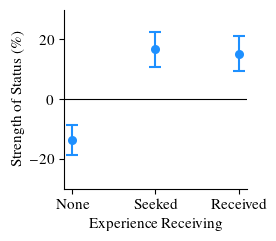

In [7]:
filtered_df = df_bounty[(df_bounty['numQuestionsAskedAT'].isin([0, 1])) & (df_bounty['numHelpProvidedAT'] < 3)]
user_ids_both_0_and_1 = filtered_df.groupby('userId')['numQuestionsAskedAT'].apply(lambda x: set(x) == {0, 1}).reset_index()
user_ids_both_0_and_1 = user_ids_both_0_and_1[user_ids_both_0_and_1['numQuestionsAskedAT'] == True]['userId']
filtered_df = filtered_df[filtered_df['userId'].isin(user_ids_both_0_and_1)]

mean_isBounty_by_user = filtered_df.groupby('userId')['isBounty'].transform('mean')
filtered_df['isBountyUserFE'] = filtered_df['isBounty'] - mean_isBounty_by_user
filtered_df['logtimeSinceFirstActivityDays'] = np.log(1 + filtered_df['timeSinceFirstActivityDays'])

# Define the logistic regression formula
formula = 'isBountyUserFE ~ C(initialExperienceReceiving) + logtimeSinceFirstActivityDays + C(year)'

# Fit the logistic model using the formula and clustered standard errors
model_social1 = smf.ols(formula=formula, data=filtered_df).fit(cov_type='cluster', cov_kwds={'groups': filtered_df['userId']})

def set_size(width=433.62, fraction=1, height_scale=1.0, equal_height_to_fraction_1=False):
    """
    Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width : float
        The document's text width in points.
    fraction : float
        The fraction of the width that the figure should occupy.
    height_scale : float
        A factor to scale the figure's height.
        - 1.0 (default): Uses the standard golden ratio height.
        - > 1.0: Makes the plot taller.
        - < 1.0: Makes the plot shorter.
    equal_height_to_fraction_1 : bool
        If True, calculates height based on the full document width, not the
        fractional width.
    """
    # Calculate the width in inches
    fig_width_pt = width * fraction
    inches_per_pt = 1 / 72.27
    fig_width_in = fig_width_pt * inches_per_pt

    # Use the golden ratio for a pleasing aspect ratio
    golden_ratio = (5**0.5 - 1) / 2

    # Determine the base height
    if equal_height_to_fraction_1:
        # Base height is calculated from the full document width (makes it tall)
        base_height_in = (width * inches_per_pt) * golden_ratio
    else:
        # Base height is calculated from the fractional figure width
        base_height_in = fig_width_in * golden_ratio

    # Apply the custom height scaling factor
    fig_height_in = base_height_in * height_scale

    return (fig_width_in, fig_height_in)

def create_bounty_plot_from_model(model, df_bounty):
    """
    Creates a plot from the bounty OLS model results.

    This function assumes the model was fitted with 'isBountyUserFE' as the
    dependent variable and 'C(initialExperienceReceiving)' as a predictor,
    with 'helped' set as the reference category.
    """
    # =============================================================================
    # 1. Define Coefficient Names Based on Your Model
    # =============================================================================
    # These names must exactly match the output of model.summary()
    intercept_name = 'Intercept'
    help_seeked_coef_name = 'C(initialExperienceReceiving)[T.help seeked]'
    no_help_seeked_coef_name = 'C(initialExperienceReceiving)[T.no help seeked]'

    # =============================================================================
    # 2. Extract Coefficients and Calculate Combined Effects & Standard Errors
    # =============================================================================
    params = model.params
    vcov = model.cov_params()

    # --- Calculate total effects for each group ---
    # The effect for "helped" (the reference level) is the Intercept itself.
    effect_helped = params[intercept_name]

    # The effect for "help seeked" is the Intercept + its specific contrast term.
    effect_help_seeked = params[intercept_name] + params[help_seeked_coef_name]

    # The effect for "no help seeked" is the Intercept + its specific contrast term.
    effect_no_help_seeked = params[intercept_name] + params[no_help_seeked_coef_name]

    # --- Calculate standard errors for the effects ---
    # SE for "helped" is the SE of the Intercept.
    se_helped = model.bse[intercept_name]

    # SE for "help seeked" must be calculated from the covariance matrix.
    # Var(A+B) = Var(A) + Var(B) + 2*Cov(A,B)
    var_intercept = vcov.loc[intercept_name, intercept_name]
    var_help_seeked = vcov.loc[help_seeked_coef_name, help_seeked_coef_name]
    cov_intercept_help_seeked = vcov.loc[intercept_name, help_seeked_coef_name]
    se_help_seeked = np.sqrt(var_intercept + var_help_seeked + 2 * cov_intercept_help_seeked)

    # SE for "no help seeked" is also calculated from the covariance matrix.
    var_no_help_seeked = vcov.loc[no_help_seeked_coef_name, no_help_seeked_coef_name]
    cov_intercept_no_help_seeked = vcov.loc[intercept_name, no_help_seeked_coef_name]
    se_no_help_seeked = np.sqrt(var_intercept + var_no_help_seeked + 2 * cov_intercept_no_help_seeked)

    # =============================================================================
    # 3. Normalize to Percentage and Generate Plot
    # =============================================================================
    # Calculate the population mean from the original, un-demeaned 'isBounty' data
    pop_mean_isBounty = df_bounty['isBounty'].mean()
    if pop_mean_isBounty == 0:
        print("Warning: Population mean of isBounty is zero. Percentage effect size cannot be calculated.")
        pop_mean_isBounty = 1 # Avoid division by zero

    # Create a DataFrame for plotting in a logical order
    plot_data = pd.DataFrame({
        'Category': [r'None', r'Seeked', r'Received'],
        'Effect': [effect_no_help_seeked, effect_help_seeked, effect_helped],
        'StdError': [se_no_help_seeked, se_help_seeked, se_helped]
    })

    # Convert to percentage effect size relative to the population mean of isBounty
    plot_data['Effect_Percent'] = (plot_data['Effect'] / pop_mean_isBounty) * 100
    plot_data['StdError_Percent'] = (plot_data['StdError'] / pop_mean_isBounty) * 100

    # --- Plot Generation ---
    plt.rcParams['text.latex.preamble'] = r"\usepackage{txfonts}"
    params = {'text.usetex': True, 'font.size': 11, 'font.family': 'serif'}
    plt.rcParams.update(params)

    fig, ax = plt.subplots(figsize=set_size(fraction=0.48, height_scale=0.7, equal_height_to_fraction_1=True))

    ax.errorbar(
        x=plot_data['Category'],
        y=plot_data['Effect_Percent'],
        yerr=plot_data['StdError_Percent'],
        marker='o',
        linestyle='None',
        capsize=4,
        color='dodgerblue',
        elinewidth=1.5,
        markeredgewidth=1.5,
        markersize=5
    )

    ax.set_ylim(-30, 30)

    ax.set_ylabel('Strength of Status (\\%)') # CHANGED Y-AXIS LABEL
    ax.set_xlabel('Experience Receiving')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.grid(True, linestyle='None', which='major', color='gray', alpha=0.5)
    ax.set_axisbelow(True)
    fig.tight_layout()

    output_filename = "../plots/status_motives_exp_receiving.eps"
    plt.savefig(output_filename, format='eps', dpi=1000, bbox_inches='tight')
    plt.show()

# Example usage:
create_bounty_plot_from_model(model=model_social1, df_bounty=df_bounty)

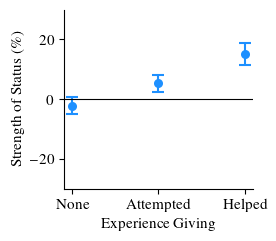

In [8]:
filtered_df = df_bounty[(df_bounty['numQuestionsAskedAT'] > 0) & (df_bounty['numHelpProvidedAT'].isin([0, 1]))]
user_ids_both_0_and_1 = filtered_df.groupby('userId')['numHelpProvidedAT'].apply(lambda x: set(x) == {0, 1}).reset_index()
user_ids_both_0_and_1 = user_ids_both_0_and_1[user_ids_both_0_and_1['numHelpProvidedAT'] == True]['userId']
filtered_df = filtered_df[filtered_df['userId'].isin(user_ids_both_0_and_1)]

mean_isBounty_by_user = filtered_df.groupby('userId')['isBounty'].transform('mean')
filtered_df['isBountyUserFE'] = filtered_df['isBounty'] - mean_isBounty_by_user

# Define the logistic regression formula
formula = 'isBountyUserFE ~ initialExperienceGiving + logtimeSinceFirstActivityDays + logNumQuestionsAskedAT  + C(year)'

# Fit the logistic model using the formula and clustered standard errors
model_social2 = smf.ols(formula=formula, data=filtered_df).fit(cov_type='cluster', cov_kwds={'groups': filtered_df['userId']})

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

def set_size(width=433.62, fraction=1, height_scale=1.0, equal_height_to_fraction_1=False):
    """
    Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width : float
        The document's text width in points.
    fraction : float
        The fraction of the width that the figure should occupy.
    height_scale : float
        A factor to scale the figure's height.
        - 1.0 (default): Uses the standard golden ratio height.
        - > 1.0: Makes the plot taller.
        - < 1.0: Makes the plot shorter.
    equal_height_to_fraction_1 : bool
        If True, calculates height based on the full document width, not the
        fractional width.
    """
    # Calculate the width in inches
    fig_width_pt = width * fraction
    inches_per_pt = 1 / 72.27
    fig_width_in = fig_width_pt * inches_per_pt

    # Use the golden ratio for a pleasing aspect ratio
    golden_ratio = (5**0.5 - 1) / 2

    # Determine the base height
    if equal_height_to_fraction_1:
        # Base height is calculated from the full document width (makes it tall)
        base_height_in = (width * inches_per_pt) * golden_ratio
    else:
        # Base height is calculated from the fractional figure width
        base_height_in = fig_width_in * golden_ratio

    # Apply the custom height scaling factor
    fig_height_in = base_height_in * height_scale

    return (fig_width_in, fig_height_in)

def create_giving_plot_from_model(model, df_bounty):
    """
    Creates a plot from the bounty OLS model results for experience giving.

    This function assumes the model was fitted with 'isBountyUserFE' as the
    dependent variable and 'initialExperienceGiving' as a predictor,
    with 'Help attempted' set as the reference category.
    """
    # =============================================================================
    # 1. Define Coefficient Names Based on Your Model
    # =============================================================================
    # These names must exactly match the output of model.summary()
    intercept_name = 'Intercept'
    helped_coef_name = 'initialExperienceGiving[T.helped]'
    no_help_attempted_coef_name = 'initialExperienceGiving[T.no help attempted]'

    # =============================================================================
    # 2. Extract Coefficients and Calculate Combined Effects & Standard Errors
    # =============================================================================
    params = model.params
    vcov = model.cov_params()

    # --- Calculate total effects for each group ---
    # The effect for "Help attempted" (the reference level) is the Intercept itself.
    effect_help_attempted = params[intercept_name]

    # The effect for "helped" is the Intercept + its specific contrast term.
    effect_helped = params[intercept_name] + params[helped_coef_name]

    # The effect for "no help attempted" is the Intercept + its specific contrast term.
    effect_no_help_attempted = params[intercept_name] + params[no_help_attempted_coef_name]

    # --- Calculate standard errors for the effects ---
    # SE for "Help attempted" is the SE of the Intercept.
    se_help_attempted = model.bse[intercept_name]

    # SE for "helped" must be calculated from the covariance matrix.
    # Var(A+B) = Var(A) + Var(B) + 2*Cov(A,B)
    var_intercept = vcov.loc[intercept_name, intercept_name]
    var_helped = vcov.loc[helped_coef_name, helped_coef_name]
    cov_intercept_helped = vcov.loc[intercept_name, helped_coef_name]
    se_helped = np.sqrt(var_intercept + var_helped + 2 * cov_intercept_helped)

    # SE for "no help attempted" is also calculated from the covariance matrix.
    var_no_help_attempted = vcov.loc[no_help_attempted_coef_name, no_help_attempted_coef_name]
    cov_intercept_no_help_attempted = vcov.loc[intercept_name, no_help_attempted_coef_name]
    se_no_help_attempted = np.sqrt(var_intercept + var_no_help_attempted + 2 * cov_intercept_no_help_attempted)

    # =============================================================================
    # 3. Normalize to Percentage and Generate Plot
    # =============================================================================
    # Calculate the population mean from the original, un-demeaned 'isBounty' data
    pop_mean_isBounty = df_bounty['isBounty'].mean()
    if pop_mean_isBounty == 0:
        print("Warning: Population mean of isBounty is zero. Percentage effect size cannot be calculated.")
        pop_mean_isBounty = 1 # Avoid division by zero

    # Create a DataFrame for plotting in a logical order
    plot_data = pd.DataFrame({
        'Category': [r'None', r'Attempted', r'Helped'],
        'Effect': [effect_no_help_attempted, effect_help_attempted, effect_helped],
        'StdError': [se_no_help_attempted, se_help_attempted, se_helped]
    })

    # Convert to percentage effect size relative to the population mean of isBounty
    plot_data['Effect_Percent'] = (plot_data['Effect'] / pop_mean_isBounty) * 100
    plot_data['StdError_Percent'] = (plot_data['StdError'] / pop_mean_isBounty) * 100

    # --- Plot Generation ---
    plt.rcParams['text.latex.preamble'] = r"\usepackage{txfonts}"
    params = {'text.usetex': True, 'font.size': 11, 'font.family': 'serif'}
    plt.rcParams.update(params)

    fig, ax = plt.subplots(figsize=set_size(fraction=0.48, height_scale=0.7, equal_height_to_fraction_1=True))

    ax.errorbar(
        x=plot_data['Category'],
        y=plot_data['Effect_Percent'],
        yerr=plot_data['StdError_Percent'],
        marker='o',
        linestyle='None',
        capsize=4,
        color='dodgerblue',
        elinewidth=1.5,
        markeredgewidth=1.5,
        markersize=5
    )
    ax.set_ylim(-30, 30)

    ax.set_ylabel('Strength of Status (\\%)')
    ax.set_xlabel('Experience Giving')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.grid(True, linestyle='None', which='major', color='gray', alpha=0.5)
    ax.set_axisbelow(True)
    fig.tight_layout()

    output_filename = "../plots/status_motives_exp_giving.eps"
    plt.savefig(output_filename, format='eps', dpi=1000, bbox_inches='tight')
    plt.show()

create_giving_plot_from_model(model=model_social2, df_bounty=filtered_df)

In [13]:
stargazer = Stargazer([model_rec1, model_social1])
stargazer.significant_digits(3)
stargazer.show_degrees_of_freedom(False)
stargazer.show_model_numbers(True)
latex_output = stargazer.render_latex()
print(latex_output)

\begin{table}[!htbp] \centering
\begin{tabular}{@{\extracolsep{5pt}}lcc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
\\[-1.8ex] & (1) & (2) \\
\hline \\[-1.8ex]
 C(hasAnswer)[T.1] & 0.020$^{***}$ & \\
& (0.003) & \\
 C(hasAnswer)[T.1]:logtimeSinceFirstActivityDays & -0.001$^{**}$ & \\
& (0.001) & \\
 C(initialExperienceReceiving)[T.help seeked] & 0.001$^{}$ & 0.000$^{}$ \\
& (0.002) & (0.000) \\
 C(initialExperienceReceiving)[T.help seeked]:C(hasAnswer)[T.1] & -0.004$^{**}$ & \\
& (0.002) & \\
 C(initialExperienceReceiving)[T.no help seeked] & -0.017$^{***}$ & -0.003$^{***}$ \\
& (0.003) & (0.001) \\
 C(initialExperienceReceiving)[T.no help seeked]:C(hasAnswer)[T.1] & -0.028$^{***}$ & \\
& (0.004) & \\
 C(phase)[T.2] & -0.045$^{***}$ & \\
& (0.004) & \\
 C(phase)[T.2]:C(hasAnswer)[T.1] & -0.036$^{***}$ & \\
& (0.005) & \\
 C(phase)[T.2]:C(hasAnswer)[T.1]:logtimeSinceFirstActivityDays & 0.006$^{***}$ & \\
& (0.001) & \\
 C(phase)[T.2]:C(initialExperienceReceiving)[T.help seeked] & 0.013$^{***}$ 

In [14]:
stargazer = Stargazer([model_rec2, model_social2])
stargazer.significant_digits(3)
stargazer.show_degrees_of_freedom(False)
stargazer.show_model_numbers(True)
latex_output = stargazer.render_latex()
print(latex_output)

\begin{table}[!htbp] \centering
\begin{tabular}{@{\extracolsep{5pt}}lcc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
\\[-1.8ex] & (1) & (2) \\
\hline \\[-1.8ex]
 C(hasAnswer)[T.1] & 0.028$^{***}$ & \\
& (0.006) & \\
 C(hasAnswer)[T.1]:logtimeSinceFirstActivityDays & -0.001$^{}$ & \\
& (0.001) & \\
 C(initialExperienceGiving)[T.helped] & 0.020$^{**}$ & \\
& (0.008) & \\
 C(initialExperienceGiving)[T.helped]:C(hasAnswer)[T.1] & 0.003$^{}$ & \\
& (0.009) & \\
 C(initialExperienceGiving)[T.no help attempted] & 0.023$^{***}$ & \\
& (0.004) & \\
 C(initialExperienceGiving)[T.no help attempted]:C(hasAnswer)[T.1] & -0.048$^{***}$ & \\
& (0.004) & \\
 C(phase)[T.2] & -0.093$^{***}$ & \\
& (0.008) & \\
 C(phase)[T.2]:C(hasAnswer)[T.1] & -0.007$^{}$ & \\
& (0.010) & \\
 C(phase)[T.2]:C(hasAnswer)[T.1]:logtimeSinceFirstActivityDays & 0.002$^{}$ & \\
& (0.001) & \\
 C(phase)[T.2]:C(initialExperienceGiving)[T.helped] & -0.033$^{***}$ & \\
& (0.011) & \\
 C(phase)[T.2]:C(initialExperienceGiving)[T.helped]:C(h

In [11]:
stargazer = Stargazer([model_rec1, model_rec2, model_social1, model_social2])
stargazer.significant_digits(3)
stargazer.show_degrees_of_freedom(False)
stargazer.show_model_numbers(True)
latex_output = stargazer.render_latex()
print(latex_output)

\begin{table}[!htbp] \centering
\begin{tabular}{@{\extracolsep{5pt}}lcccc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
\\[-1.8ex] & (1) & (2) & (3) & (4) \\
\hline \\[-1.8ex]
 C(hasAnswer)[T.1] & 0.020$^{***}$ & 0.028$^{***}$ & & \\
& (0.003) & (0.006) & & \\
 C(hasAnswer)[T.1]:logtimeSinceFirstActivityDays & -0.001$^{**}$ & -0.001$^{}$ & & \\
& (0.001) & (0.001) & & \\
 C(initialExperienceGiving)[T.helped] & & 0.020$^{**}$ & & \\
& & (0.008) & & \\
 C(initialExperienceGiving)[T.helped]:C(hasAnswer)[T.1] & & 0.003$^{}$ & & \\
& & (0.009) & & \\
 C(initialExperienceGiving)[T.no help attempted] & & 0.023$^{***}$ & & \\
& & (0.004) & & \\
 C(initialExperienceGiving)[T.no help attempted]:C(hasAnswer)[T.1] & & -0.048$^{***}$ & & \\
& & (0.004) & & \\
 C(initialExperienceReceiving)[T.help seeked] & 0.001$^{}$ & & 0.000$^{}$ & \\
& (0.002) & & (0.000) & \\
 C(initialExperienceReceiving)[T.help seeked]:C(hasAnswer)[T.1] & -0.004$^{**}$ & & & \\
& (0.002) & & & \\
 C(initialExperienceReceiving)[T.no hel